<a href="https://colab.research.google.com/github/JohnnyPoks/machine-learning-and-computer-vision/blob/main/MCF631_FaceVerification_POKAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Enviroment setup and Initialization**

In [ ]:
# ensure typical Python packages we will use are installed
# - -q makes pip quiet so output is less noisy
!pip install -q scikit-learn matplotlib pillow

In [ ]:
# mount Google Drive so we can save/cache dataset and outputs there
from google.colab import drive
drive.mount('/content/drive')

# create a project directory inside MyDrive for this project
# if the folder already exists, this command will do nothing harmful
import os
PROJECT_DIR = "/content/drive/MyDrive/MCF631_FaceVerification_POKAM"
os.makedirs(PROJECT_DIR, exist_ok=True)
print("Project folder:", PROJECT_DIR)

Mounted at /content/drive
Project folder: /content/drive/MyDrive/MCF631_FaceVerification_POKAM


# **2. Data Collection**

In [ ]:
# import commonly used libraries and functions
# we'll use sklearn to load LFW pairs (good for verification tasks)
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_lfw_pairs, fetch_lfw_people

# set a nicer default for plots
plt.rcParams['figure.figsize'] = (10,4)

In [ ]:
# load the LFW verification pairs dataset and cache it into our Drive folder
# data_home points to our Drive location so the dataset files live there
# resize=0.5 reduces image size to speed up things (you can increase later)
lfw_pairs_train = fetch_lfw_pairs(subset='train', resize=0.5, data_home=PROJECT_DIR, download_if_missing=True)
lfw_pairs_test  = fetch_lfw_pairs(subset='test',  resize=0.5, data_home=PROJECT_DIR, download_if_missing=True)

# print a short summary so we can see what's inside
print("Train keys:", list(lfw_pairs_train.keys()))
print("Number of train pairs:", len(lfw_pairs_train.pairs))
print("Number of test pairs:", len(lfw_pairs_test.pairs))

Train keys: ['data', 'pairs', 'target', 'target_names', 'DESCR']
Number of train pairs: 2200
Number of test pairs: 1000


In [ ]:
# look into the structure of one of the returned objects
# .pairs has shape (n_samples, 2, height, width) for grayscale images
pairs = lfw_pairs_train.pairs
targets = lfw_pairs_train.target

# print shapes and a quick distribution of labels
print("pairs shape (train):", pairs.shape)
print("targets shape (train):", targets.shape)
print("unique target values (0=diff, 1=same):", np.unique(targets, return_counts=True))
# show image height and width
print("image HxW:", pairs.shape[2], "x", pairs.shape[3])

pairs shape (train): (2200, 2, 62, 47)
targets shape (train): (2200,)
unique target values (0=diff, 1=same): (array([0, 1]), array([1100, 1100]))
image HxW: 62 x 47


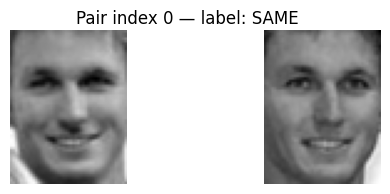

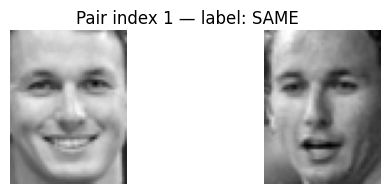

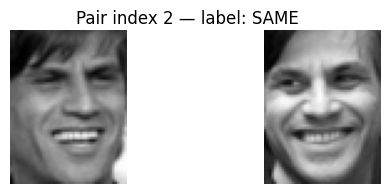

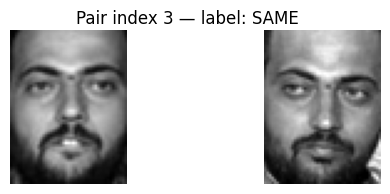

In [ ]:
# function to display N sample pairs from a dataset object
def show_sample_pairs(dataset, start=0, n=4):
    # dataset.pairs is (n_pairs, 2, H, W)
    pairs = dataset.pairs
    targets = dataset.target
    for i in range(start, start+n):
        img1 = pairs[i,0]   # first image of the pair
        img2 = pairs[i,1]   # second image of the pair
        label = targets[i]  # 1 -> same person, 0 -> different persons

        # plot side-by-side
        plt.figure(figsize=(6,2))
        plt.suptitle(f"Pair index {i} — label: {'SAME' if label==1 else 'DIFFERENT'}")
        plt.subplot(1,2,1)
        plt.imshow(img1, cmap='gray')
        plt.axis('off')
        plt.subplot(1,2,2)
        plt.imshow(img2, cmap='gray')
        plt.axis('off')
        plt.show()

# show first 4 training pairs for inspection
show_sample_pairs(lfw_pairs_train, start=0, n=4)

# **3. Data Preprocessing**

In [ ]:
# Check that torch and torchvision are available (install only if missing)
# printing the torch version to confirm GPU availability
import importlib
import sys

try:
    import torch
    import torchvision
    print("torch version:", torch.__version__)
    # check if GPU is available in Colab
    if torch.cuda.is_available():
      print("cuda available:", torch.cuda.is_available())
      print("CUDA device name:", torch.cuda.get_device_name(0))
    else:
      print("No CUDA device detected in this session.")
except Exception as e:
    # If torch is missing, install it (Colab usually has torch preinstalled)
    !pip install -q torch torchvision
    import torch, torchvision
    print("Installed torch version:", torch.__version__)
    print("cuda available:", torch.cuda.is_available())

torch version: 2.10.0+cu128
cuda available: True
CUDA device name: Tesla T4


In [ ]:
# Create a simple PyTorch Dataset class that wraps sklearn's fetch_lfw_pairs output
# The dataset will return (img_tensor1, img_tensor2, label)
import torch
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms

# transformation pipeline for images (convert to 3 channels, resize, normalize)
# - we convert grayscale to RGB by duplicating the channel (some pretrained nets expect 3 channels)
# - resize to 224x224 (standard for ResNet) to match pretrained model input
# - convert to tensor and normalize with ImageNet mean/std because we use pretrained weights
image_transform = transforms.Compose([
    transforms.ToPILImage(),                      # convert numpy array (H,W) -> PIL Image
    transforms.Resize((224,224)),                 # resize to 224x224
    transforms.Grayscale(num_output_channels=3), # convert to 3-channel RGB-like
    transforms.ToTensor(),                        # convert to tensor in [0,1]
    transforms.Normalize(                         # normalize with ImageNet stats
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class LFWPairsDataset(Dataset):
    def __init__(self, lfw_pairs_obj, transform=None):
        # store the pairs and labels from sklearn object
        self.pairs = lfw_pairs_obj.pairs      # shape (n_pairs, 2, H, W)
        self.targets = lfw_pairs_obj.target   # 0 or 1
        self.transform = transform

    def __len__(self):
        # return how many pairs exist
        return len(self.targets)

    def __getitem__(self, idx):
        # get the two images (as numpy arrays) and the label
        img1 = self.pairs[idx,0]   # first image (H,W) grayscale
        img2 = self.pairs[idx,1]   # second image
        label = int(self.targets[idx])

        # apply transform if provided (convert to PyTorch tensors ready for model)
        if self.transform is not None:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, label

# instantiate dataset for train object you already loaded earlier
train_dataset_full = LFWPairsDataset(lfw_pairs_train, transform=image_transform)
print("Total train pairs available:", len(train_dataset_full))
# show shape of a single returned item (without running dataloader)
sample_img1, sample_img2, sample_label = train_dataset_full[0]
print("Single sample shapes:", sample_img1.shape, sample_img2.shape, "label:", sample_label)

Total train pairs available: 2200
Single sample shapes: torch.Size([3, 224, 224]) torch.Size([3, 224, 224]) label: 1


In [ ]:
# Split the 2200 train pairs into training and validation subsets (80/20 split)
from torch.utils.data import random_split, DataLoader

total_pairs = len(train_dataset_full)
train_size = int(0.8 * total_pairs)  # recommended: 1760
val_size = total_pairs - train_size   # recommended: 440

# perform the split (uses random generator; set seed for reproducibility)
torch.manual_seed(42)
train_dataset, val_dataset = random_split(train_dataset_full, [train_size, val_size])

# create DataLoader objects for batching (we'll use small batch sizes for embedding extraction)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)

print("Train pairs (after split):", len(train_dataset))
print("Validation pairs:", len(val_dataset))
# peek one batch to show shapes
for batch in train_loader:
    b_img1, b_img2, b_label = batch
    print("Batch shapes -> img1:", b_img1.shape, "img2:", b_img2.shape, "labels:", b_label.shape)
    break

Train pairs (after split): 1760
Validation pairs: 440
Batch shapes -> img1: torch.Size([32, 3, 224, 224]) img2: torch.Size([32, 3, 224, 224]) labels: torch.Size([32])


In [ ]:
# Build a feature extractor from pretrained ResNet18
import torchvision.models as models
import torch.nn as nn
import torch

# create the model and remove the final classification head
# we'll use the network up to the average pool output as embedding
model_resnet = models.resnet18(pretrained=True)
# replace the final fully connected layer with identity so forward() returns feature map before fc
# Option A: set model.fc to identity and then flatten output
class Identity(nn.Module):
    def forward(self, x):
        return x

model_resnet.fc = Identity()

# check device: GPU if available else CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_resnet = model_resnet.to(device)
model_resnet.eval()  # set to evaluation mode (important for batchnorm / dropout)
print("Model loaded, device:", device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 89.9MB/s]


Model loaded, device: cuda


In [ ]:
# Run one batch through the model to get embeddings and check shapes
import torch

# get one batch from the train_loader
batch_img1, batch_img2, batch_labels = next(iter(train_loader))

# move tensors to device
batch_img1 = batch_img1.to(device)
batch_img2 = batch_img2.to(device)

# with torch.no_grad() to avoid gradient computation (saves memory)
with torch.no_grad():
    emb1 = model_resnet(batch_img1)  # shape: [batch, feature_dims, 1, 1] or [batch, feature_dims]
    emb2 = model_resnet(batch_img2)

# flatten embeddings if needed
emb1 = emb1.view(emb1.size(0), -1)
emb2 = emb2.view(emb2.size(0), -1)

# L2 normalize embeddings (common practice)
emb1_norm = torch.nn.functional.normalize(emb1, p=2, dim=1)
emb2_norm = torch.nn.functional.normalize(emb2, p=2, dim=1)

print("Embedding shapes:", emb1.shape, emb2.shape)
print("Normalized embedding shapes:", emb1_norm.shape, emb2_norm.shape)
# compute cosine similarity for the first 5 pairs as a sanity check
cos_sim = torch.sum(emb1_norm * emb2_norm, dim=1)  # because L2-normalized, dot = cosine
print("Sample cosine similarities (first 5):", cos_sim[:5].cpu().numpy())

Embedding shapes: torch.Size([32, 512]) torch.Size([32, 512])
Normalized embedding shapes: torch.Size([32, 512]) torch.Size([32, 512])
Sample cosine similarities (first 5): [0.81198573 0.90437084 0.60906065 0.8577397  0.79246455]


# **Extract and save embeddings for the entire datasets (train/val/test)**

In [ ]:
# create DataLoader for the test pairs and save embeddings for train/val/test
# - assumes model_resnet (feature extractor), device, train_loader, val_loader already exist
# - saves numpy files to PROJECT_DIR for quick later use

import os
import numpy as np
import torch
from torch.utils.data import DataLoader

# creating a DataLoader for the test pairs (we wrapped train earlier; do same for test)
test_dataset = LFWPairsDataset(lfw_pairs_test, transform=image_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# helper: extract embeddings from a loader and return numpy arrays
def extract_embeddings(loader, model, device):
    emb1_list = []
    emb2_list = []
    labels_list = []
    model.eval()
    with torch.no_grad():
        for img1, img2, labels in loader:
            img1 = img1.to(device)
            img2 = img2.to(device)
            # forward pass to get embeddings
            e1 = model(img1)
            e2 = model(img2)
            # flatten
            e1 = e1.view(e1.size(0), -1)
            e2 = e2.view(e2.size(0), -1)
            # L2 normalize
            e1 = torch.nn.functional.normalize(e1, p=2, dim=1)
            e2 = torch.nn.functional.normalize(e2, p=2, dim=1)
            # move to CPU and append as numpy
            emb1_list.append(e1.cpu().numpy())
            emb2_list.append(e2.cpu().numpy())
            labels_list.append(labels.numpy())
    emb1_all = np.vstack(emb1_list)
    emb2_all = np.vstack(emb2_list)
    labels_all = np.hstack(labels_list)
    return emb1_all, emb2_all, labels_all

# Extract embeddings for train, val, test
print("Extracting train embeddings...")
train_e1, train_e2, train_labels = extract_embeddings(train_loader, model_resnet, device)
print("Extracting val embeddings...")
val_e1, val_e2, val_labels = extract_embeddings(val_loader, model_resnet, device)
print("Extracting test embeddings...")
test_e1, test_e2, test_labels = extract_embeddings(test_loader, model_resnet, device)

# Save to Drive (PROJECT_DIR)
np.save(os.path.join(PROJECT_DIR, "train_e1.npy"), train_e1)
np.save(os.path.join(PROJECT_DIR, "train_e2.npy"), train_e2)
np.save(os.path.join(PROJECT_DIR, "train_labels.npy"), train_labels)

np.save(os.path.join(PROJECT_DIR, "val_e1.npy"), val_e1)
np.save(os.path.join(PROJECT_DIR, "val_e2.npy"), val_e2)
np.save(os.path.join(PROJECT_DIR, "val_labels.npy"), val_labels)

np.save(os.path.join(PROJECT_DIR, "test_e1.npy"), test_e1)
np.save(os.path.join(PROJECT_DIR, "test_e2.npy"), test_e2)
np.save(os.path.join(PROJECT_DIR, "test_labels.npy"), test_labels)

print("Saved embeddings to DRIVE project folder:", PROJECT_DIR)
print("Train shapes:", train_e1.shape, train_e2.shape, train_labels.shape)
print("Val shapes:  ", val_e1.shape, val_e2.shape, val_labels.shape)
print("Test shapes: ", test_e1.shape, test_e2.shape, test_labels.shape)

Extracting train embeddings...
Extracting val embeddings...
Extracting test embeddings...
Saved embeddings to DRIVE project folder: /content/drive/MyDrive/MCF631_FaceVerification_POKAM
Train shapes: (1760, 512) (1760, 512) (1760,)
Val shapes:   (440, 512) (440, 512) (440,)
Test shapes:  (1000, 512) (1000, 512) (1000,)


# **Baseline evaluation on validation set (cosine similarity threshold + ROC/AUC + best threshold)**

In [ ]:
# Load saved embeddings and compute validation ROC, AUC, best threshold and EER
# - requires scikit-learn for ROC functions (already installed)
import numpy as np
from sklearn.metrics import roc_curve, auc, accuracy_score

# load embeddings from drive
train_e1 = np.load(os.path.join(PROJECT_DIR, "train_e1.npy"))
train_e2 = np.load(os.path.join(PROJECT_DIR, "train_e2.npy"))
train_labels = np.load(os.path.join(PROJECT_DIR, "train_labels.npy"))

val_e1 = np.load(os.path.join(PROJECT_DIR, "val_e1.npy"))
val_e2 = np.load(os.path.join(PROJECT_DIR, "val_e2.npy"))
val_labels = np.load(os.path.join(PROJECT_DIR, "val_labels.npy"))

# compute cosine similarity (dot product because embeddings are L2-normalized)
val_sim = np.sum(val_e1 * val_e2, axis=1)

# compute ROC and AUC
fpr, tpr, thresholds = roc_curve(val_labels, val_sim)
roc_auc = auc(fpr, tpr)

# find threshold that maximizes accuracy on validation set
best_acc = 0.0
best_thresh = 0.0
for thr in thresholds:
    preds = (val_sim >= thr).astype(int)
    acc = accuracy_score(val_labels, preds)
    if acc > best_acc:
        best_acc = acc
        best_thresh = thr

# compute EER: find point where FPR ~ (1 - TPR)
# EER is the threshold where False Positive Rate and False Negative Rate are equal.
fnr = 1 - tpr
eer_idx = np.nanargmin(np.abs(fnr - fpr))
eer = (fpr[eer_idx] + fnr[eer_idx]) / 2.0  # approximate EER

print("Validation AUC:", roc_auc)
print("Best validation accuracy:", best_acc, "at threshold:", best_thresh)
print("Approximate EER (on val):", eer)

Validation AUC: 0.7306802215059096
Best validation accuracy: 0.6840909090909091 at threshold: 0.8768878
Approximate EER (on val): 0.33184560707496485


# **Evaluate baseline on the test set (use best threshold found on validation)**

In [ ]:
# load numpy and sklearn metrics we need
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

# load embeddings and labels from Drive (we saved these earlier)
# train_e1, train_e2 not needed here but we keep them if you want to inspect later
val_e1 = np.load(os.path.join(PROJECT_DIR, "val_e1.npy"))
val_e2 = np.load(os.path.join(PROJECT_DIR, "val_e2.npy"))
val_labels = np.load(os.path.join(PROJECT_DIR, "val_labels.npy"))

test_e1 = np.load(os.path.join(PROJECT_DIR, "test_e1.npy"))
test_e2 = np.load(os.path.join(PROJECT_DIR, "test_e2.npy"))
test_labels = np.load(os.path.join(PROJECT_DIR, "test_labels.npy"))

# compute cosine similarity on test set (dot product since embeddings are L2-normalized)
test_sim = np.sum(test_e1 * test_e2, axis=1)

# use the best threshold found earlier on validation
best_thresh = 0.8768878  # from your validation step

# compute test predictions using that threshold
test_preds_baseline = (test_sim >= best_thresh).astype(int)

# compute accuracy and confusion matrix on test
test_acc_baseline = accuracy_score(test_labels, test_preds_baseline)
cm_baseline = confusion_matrix(test_labels, test_preds_baseline)

# compute ROC and AUC on test for plotting later
fpr_test, tpr_test, thr_test = roc_curve(test_labels, test_sim)
auc_test = auc(fpr_test, tpr_test)

# print the main numbers
print("Baseline (thresholding) on TEST:")
print("Test AUC:", auc_test)
print("Test accuracy (at val threshold):", test_acc_baseline)
print("Confusion matrix (rows=true 0/1, cols=pred 0/1):")
print(cm_baseline)

Baseline (thresholding) on TEST:
Test AUC: 0.7358499999999999
Test accuracy (at val threshold): 0.672
Confusion matrix (rows=true 0/1, cols=pred 0/1):
[[382 118]
 [210 290]]


# **Train a logistic regression classifier on |e1 - e2| and evaluate on val/test**

In [ ]:
# Train logistic regression on absolute difference of embeddings
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc, confusion_matrix
import joblib  # for saving the trained model if desired

# load train and val embeddings and labels (we saved them earlier)
train_e1 = np.load(os.path.join(PROJECT_DIR, "train_e1.npy"))
train_e2 = np.load(os.path.join(PROJECT_DIR, "train_e2.npy"))
train_labels = np.load(os.path.join(PROJECT_DIR, "train_labels.npy"))

val_e1 = np.load(os.path.join(PROJECT_DIR, "val_e1.npy"))
val_e2 = np.load(os.path.join(PROJECT_DIR, "val_e2.npy"))
val_labels = np.load(os.path.join(PROJECT_DIR, "val_labels.npy"))

# prepare features: absolute difference of embeddings is a common choice
# feature vector for a pair = |embedding1 - embedding2|
X_train = np.abs(train_e1 - train_e2)
y_train = train_labels
X_val = np.abs(val_e1 - val_e2)
y_val = val_labels

# create and train logistic regression (solver lbfgs, allow more iterations)
# - C=1.0 default is fine; you can tune later
clf = LogisticRegression(max_iter=1000, solver='lbfgs')
# fit the classifier on training features
clf.fit(X_train, y_train)

# evaluate on validation set
val_preds = clf.predict(X_val)
val_acc = accuracy_score(y_val, val_preds)
print("Logistic regression - Validation accuracy:", val_acc)
print("Validation classification report:")
print(classification_report(y_val, val_preds))

# evaluate on test set
test_e1 = np.load(os.path.join(PROJECT_DIR, "test_e1.npy"))
test_e2 = np.load(os.path.join(PROJECT_DIR, "test_e2.npy"))
test_labels = np.load(os.path.join(PROJECT_DIR, "test_labels.npy"))
X_test = np.abs(test_e1 - test_e2)
y_test = test_labels

test_preds = clf.predict(X_test)
test_acc = accuracy_score(y_test, test_preds)
print("Logistic regression - Test accuracy:", test_acc)
print("Test classification report:")
print(classification_report(y_test, test_preds))

# also compute ROC and AUC for logistic (probability of class 1)
test_probs = clf.predict_proba(X_test)[:,1]
fpr_log, tpr_log, thr_log = roc_curve(y_test, test_probs)
auc_log = auc(fpr_log, tpr_log)
print("Logistic test AUC:", auc_log)

# save model to Drive so you can reuse it later
model_path = os.path.join(PROJECT_DIR, "logreg_pair_model.joblib")
joblib.dump(clf, model_path)
print("Saved logistic model to:", model_path)

Logistic regression - Validation accuracy: 0.725
Validation classification report:
              precision    recall  f1-score   support

           0       0.73      0.71      0.72       218
           1       0.72      0.74      0.73       222

    accuracy                           0.72       440
   macro avg       0.73      0.72      0.72       440
weighted avg       0.73      0.72      0.72       440

Logistic regression - Test accuracy: 0.7
Test classification report:
              precision    recall  f1-score   support

           0       0.70      0.69      0.70       500
           1       0.70      0.71      0.70       500

    accuracy                           0.70      1000
   macro avg       0.70      0.70      0.70      1000
weighted avg       0.70      0.70      0.70      1000

Logistic test AUC: 0.7782280000000001
Saved logistic model to: /content/drive/MyDrive/MCF631_FaceVerification_POKAM/logreg_pair_model.joblib


# **ROC curves for baseline (similarity-threshold) and logistic classifier (probabilities)**

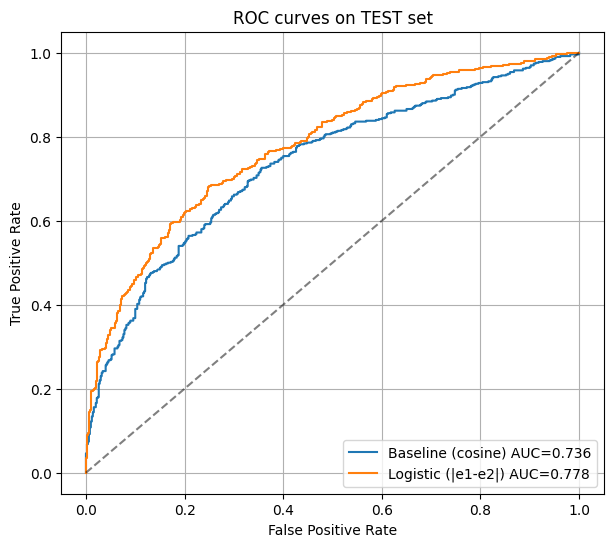

In [ ]:
# Plot ROC curves for baseline similarity and logistic regression on the test set
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# we already computed test_sim (cosine sims) in CELL 1 and test_probs (from CELL 2)
# if not present in memory, reload them:
test_sim = np.sum(test_e1 * test_e2, axis=1)  # cosine sims (baseline)
# test_probs is probability of class 1 from logistic saved in the last cell
test_probs = clf.predict_proba(X_test)[:,1]

# compute ROC and AUC for both
fpr_sim, tpr_sim, _ = roc_curve(y_test, test_sim)
auc_sim = auc(fpr_sim, tpr_sim)

fpr_log, tpr_log, _ = roc_curve(y_test, test_probs)
auc_log = auc(fpr_log, tpr_log)

# plot
plt.figure(figsize=(7,6))
plt.plot(fpr_sim, tpr_sim, label=f'Baseline (cosine) AUC={auc_sim:.3f}')
plt.plot(fpr_log, tpr_log, label=f'Logistic (|e1-e2|) AUC={auc_log:.3f}')
plt.plot([0,1],[0,1],'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves on TEST set')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# **Compute EER precisely for both methods**

In [ ]:
# compute EER for method given fpr and tpr
import numpy as np

def compute_eer(fpr, tpr, thresholds):
    # false negative rate = 1 - tpr
    fnr = 1 - tpr
    # find the index where FPR and FNR are closest
    idx = np.nanargmin(np.abs(fpr - fnr))
    eer = (fpr[idx] + fnr[idx]) / 2.0
    return eer, thresholds[idx]

# EER for baseline (cosine)
eer_sim, thr_sim = compute_eer(fpr_sim, tpr_sim, _)
# EER for logistic
eer_log, thr_log = compute_eer(fpr_log, tpr_log, _)

print("Baseline EER:", eer_sim, "at threshold (on ROC curve):", thr_sim)
print("Logistic EER:", eer_log, "at threshold (on ROC curve):", thr_log)

Baseline EER: 0.32099999999999995 at threshold (on ROC curve): 0.4905862382957009
Logistic EER: 0.30000000000000004 at threshold (on ROC curve): 0.5054236778533376


# **Save summary metrics and plot confusion matrices (baseline vs logistic)**

               method       AUC  Accuracy    EER
0   Baseline (cosine)  0.735850     0.672  0.321
1  Logistic (|e1-e2|)  0.778228     0.700  0.300
Saved metrics_summary.csv to /content/drive/MyDrive/MCF631_FaceVerification_POKAM


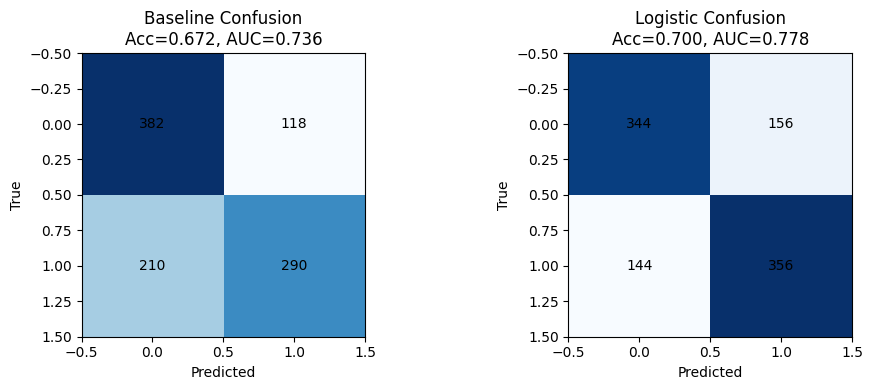

Saved confusion matrix plot to: /content/drive/MyDrive/MCF631_FaceVerification_POKAM/confusion_matrices.png


In [ ]:
# Saving metrics and plotting confusion matrices for baseline and logistic
# prints a small table and saves it to Drive for the report
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc

# --- assume these variables exist from previous steps ---
# test_labels (y_test), test_sim (cosine similarity), best_thresh (from val)
# clf (trained logistic), X_test (|e1-e2|), test_e1/test_e2 etc.
# If any variable is not in memory, we reload from DRIVE .npy files
import os
if 'test_labels' not in globals():
    test_labels = np.load(os.path.join(PROJECT_DIR, "test_labels.npy"))
if 'test_sim' not in globals():
    test_e1 = np.load(os.path.join(PROJECT_DIR, "test_e1.npy"))
    test_e2 = np.load(os.path.join(PROJECT_DIR, "test_e2.npy"))
    test_sim = np.sum(test_e1 * test_e2, axis=1)
if 'best_thresh' not in globals():
    best_thresh = 0.8768878

# Baseline predictions (thresholding)
pred_baseline = (test_sim >= best_thresh).astype(int)
acc_baseline = accuracy_score(test_labels, pred_baseline)
fpr_sim, tpr_sim, _ = roc_curve(test_labels, test_sim)
auc_baseline = auc(fpr_sim, tpr_sim)

# Logistic predictions and probs
if 'clf' not in globals():
    import joblib
    clf = joblib.load(os.path.join(PROJECT_DIR, "logreg_pair_model.joblib"))
X_test = np.abs(np.load(os.path.join(PROJECT_DIR, "test_e1.npy")) - np.load(os.path.join(PROJECT_DIR, "test_e2.npy")))
pred_log = clf.predict(X_test)
probs_log = clf.predict_proba(X_test)[:,1]
acc_log = accuracy_score(test_labels, pred_log)
fpr_log, tpr_log, _ = roc_curve(test_labels, probs_log)
auc_log = auc(fpr_log, tpr_log)

# compute EER helper
def compute_eer(fpr, tpr):
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fpr - fnr))
    return (fpr[idx] + fnr[idx]) / 2.0

eer_baseline = compute_eer(fpr_sim, tpr_sim)
eer_log = compute_eer(fpr_log, tpr_log)

# create metrics table
metrics = pd.DataFrame({
    "method": ["Baseline (cosine)", "Logistic (|e1-e2|)"],
    "AUC": [auc_baseline, auc_log],
    "Accuracy": [acc_baseline, acc_log],
    "EER": [eer_baseline, eer_log]
})

# print and save
print(metrics)
metrics.to_csv(os.path.join(PROJECT_DIR, "metrics_summary.csv"), index=False)
print("Saved metrics_summary.csv to", PROJECT_DIR)

# plot confusion matrices side-by-side and save figure
cm_bas = confusion_matrix(test_labels, pred_baseline)
cm_log = confusion_matrix(test_labels, pred_log)

fig, axs = plt.subplots(1,2, figsize=(10,4))
im0 = axs[0].imshow(cm_bas, cmap='Blues', interpolation='nearest')
axs[0].set_title(f"Baseline Confusion\nAcc={acc_baseline:.3f}, AUC={auc_baseline:.3f}")
axs[0].set_xlabel("Predicted")
axs[0].set_ylabel("True")
for (i,j), val in np.ndenumerate(cm_bas):
    axs[0].text(j, i, val, ha='center', va='center', color='black')

im1 = axs[1].imshow(cm_log, cmap='Blues', interpolation='nearest')
axs[1].set_title(f"Logistic Confusion\nAcc={acc_log:.3f}, AUC={auc_log:.3f}")
axs[1].set_xlabel("Predicted")
axs[1].set_ylabel("True")
for (i,j), val in np.ndenumerate(cm_log):
    axs[1].text(j, i, val, ha='center', va='center', color='black')

plt.tight_layout()
fig_path = os.path.join(PROJECT_DIR, "confusion_matrices.png")
plt.savefig(fig_path, bbox_inches='tight')
plt.show()
print("Saved confusion matrix plot to:", fig_path)

# **Show some false positives and false negatives (logistic model)**

Number of false positives (logistic): 156
Number of false negatives (logistic): 144
Showing false positives (pred=1, true=0):


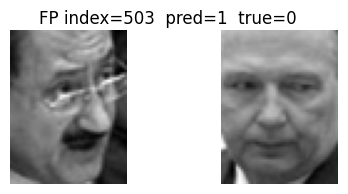

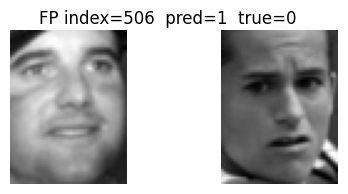

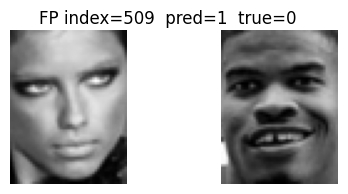

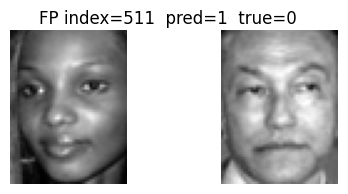

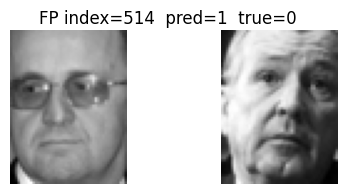

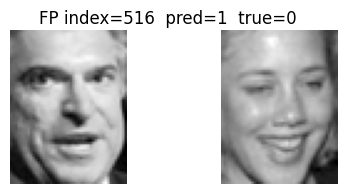

Showing false negatives (pred=0, true=1):


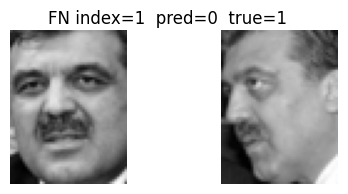

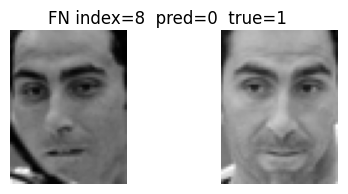

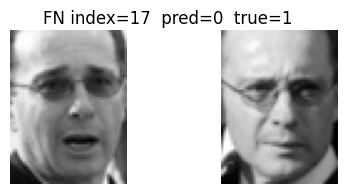

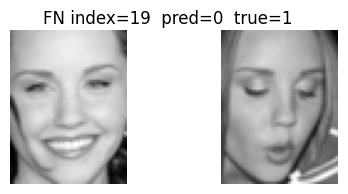

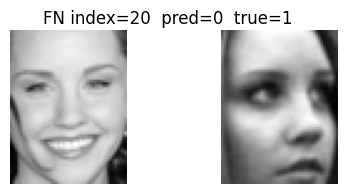

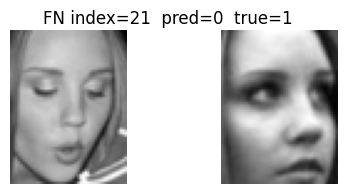

In [ ]:
# Display example false positives and false negatives for the logistic model
# We'll display up to 6 examples for each category (FP and FN)
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

test_e1 = np.load(os.path.join(PROJECT_DIR, "test_e1.npy"))
test_e2 = np.load(os.path.join(PROJECT_DIR, "test_e2.npy"))
test_labels = np.load(os.path.join(PROJECT_DIR, "test_labels.npy"))

# predict using logistic (if not in memory, load model)
import joblib
if 'clf' not in globals():
    clf = joblib.load(os.path.join(PROJECT_DIR, "logreg_pair_model.joblib"))

X_test = np.abs(test_e1 - test_e2)
pred_log = clf.predict(X_test)

# indices of false positives (pred=1 but true=0) and false negatives (pred=0 but true=1)
fp_idx = np.where((pred_log == 1) & (test_labels == 0))[0]
fn_idx = np.where((pred_log == 0) & (test_labels == 1))[0]

print("Number of false positives (logistic):", len(fp_idx))
print("Number of false negatives (logistic):", len(fn_idx))

# helper to plot a list of pair indices
from sklearn.datasets import fetch_lfw_pairs
# we will reload the lfw_pairs_test object so we can display original images (grayscale)
lfw_pairs_test = fetch_lfw_pairs(subset='test', resize=0.5, data_home=PROJECT_DIR, download_if_missing=False)

def show_pairs(indices, kind="FP", N=6):
    for i in indices[:N]:
        img1 = lfw_pairs_test.pairs[i,0]
        img2 = lfw_pairs_test.pairs[i,1]
        plt.figure(figsize=(5,2))
        plt.suptitle(f"{kind} index={i}  pred={pred_log[i]}  true={test_labels[i]}")
        plt.subplot(1,2,1); plt.imshow(img1, cmap='gray'); plt.axis('off')
        plt.subplot(1,2,2); plt.imshow(img2, cmap='gray'); plt.axis('off')
        plt.show()

# Show first few false positives and false negatives
if len(fp_idx) > 0:
    print("Showing false positives (pred=1, true=0):")
    show_pairs(fp_idx, kind="FP", N=6)
else:
    print("No false positives to show.")

if len(fn_idx) > 0:
    print("Showing false negatives (pred=0, true=1):")
    show_pairs(fn_idx, kind="FN", N=6)
else:
    print("No false negatives to show.")

In [ ]:
# Save example FP and FN pairs to Drive for inclusion in the report
# Save up to N examples each to PROJECT_DIR/FP_examples and .../FN_examples
import os
import numpy as np
from PIL import Image
import joblib

N = 6  # number of examples to save (you can lower if you want)
OUT_FP_DIR = os.path.join(PROJECT_DIR, "FP_examples")
OUT_FN_DIR = os.path.join(PROJECT_DIR, "FN_examples")
os.makedirs(OUT_FP_DIR, exist_ok=True)
os.makedirs(OUT_FN_DIR, exist_ok=True)

# load test arrays and model if needed
test_e1 = np.load(os.path.join(PROJECT_DIR, "test_e1.npy"))
test_e2 = np.load(os.path.join(PROJECT_DIR, "test_e2.npy"))
test_labels = np.load(os.path.join(PROJECT_DIR, "test_labels.npy"))
clf = joblib.load(os.path.join(PROJECT_DIR, "logreg_pair_model.joblib"))

# compute preds on test
X_test = np.abs(test_e1 - test_e2)
preds = clf.predict(X_test)

# find indices
fp_idx = np.where((preds == 1) & (test_labels == 0))[0]
fn_idx = np.where((preds == 0) & (test_labels == 1))[0]

# reload lfw_pairs_test to access original grayscale images
from sklearn.datasets import fetch_lfw_pairs
lfw_pairs_test = fetch_lfw_pairs(subset='test', resize=0.5, data_home=PROJECT_DIR, download_if_missing=False)

# helper to save image pair
def save_pair(index, out_dir, prefix):
    img1 = (lfw_pairs_test.pairs[index,0] * 255).astype(np.uint8)
    img2 = (lfw_pairs_test.pairs[index,1] * 255).astype(np.uint8)
    Image.fromarray(img1).save(os.path.join(out_dir, f"{prefix}_pair{index}_1.png"))
    Image.fromarray(img2).save(os.path.join(out_dir, f"{prefix}_pair{index}_2.png"))

# save up to N examples each
for i, idx in enumerate(fp_idx[:N]):
    save_pair(idx, OUT_FP_DIR, f"FP{i}")
for i, idx in enumerate(fn_idx[:N]):
    save_pair(idx, OUT_FN_DIR, f"FN{i}")

print("Saved", min(N,len(fp_idx)), "FPs to", OUT_FP_DIR)
print("Saved", min(N,len(fn_idx)), "FNs to", OUT_FN_DIR)

Saved 6 FPs to /content/drive/MyDrive/MCF631_FaceVerification_POKAM/FP_examples
Saved 6 FNs to /content/drive/MyDrive/MCF631_FaceVerification_POKAM/FN_examples


In [ ]:
# SOURCE CODE LINK : https://colab.research.google.com/drive/1YYm0tTKFbcYJ4t0jJFf4JFWoslfTpEd6?usp=sharing

# ARTIFACTS LINK : https://drive.google.com/drive/folders/1FHrKA_TWHqJi7A8Yd-726a-hj-YVIv72?usp=sharing